# Two-Body Weber Electrodynamics Reference

API reference demonstrating all public functions with a 2D Weber system exhibiting orbital precession.

## Weber Hamiltonian

For two charged particles:

$$H = \frac{|\mathbf{p}_1|^2}{2m_1} + \frac{|\mathbf{p}_2|^2}{2m_2} + U(r, \dot{r})$$

where the Weber potential is:

$$U = \frac{k}{r}\left(1 - \frac{\dot{r}^2}{2c^2}\right)$$

with $\dot{r} = \frac{\vec{r} \cdot \vec{v}}{r}$ the radial velocity and $k = q_1 q_2 / (4\pi\varepsilon_0)$.

For **attractive** interactions (opposite charges, $k < 0$), the velocity-dependent term causes orbital precession when $c$ is finite. This is analogous to relativistic perihelion precession in General Relativity.

In [1]:
using WeberElectrodynamics
using Plots
using LinearAlgebra

## Symbolic Variables

In [ ]:
n_particles = 2
dims = 2

q_syms, p_syms = generate_phase_space_symbols(n_particles, dims)
println("Position symbols: ", q_syms)
println("Momentum symbols: ", p_syms)

## Hamiltonian Construction

In [ ]:
# Alternative: @hamiltonian 2 2 [:m1, :m2, :k, :c] (q, p, params) -> ...
function H_weber(q, p, params)
    m1, m2, k, c = params
    x1, y1, x2, y2 = q
    px1, py1, px2, py2 = p
    
    KE = (px1^2 + py1^2)/(2m1) + (px2^2 + py2^2)/(2m2)
    
    dx, dy = x1 - x2, y1 - y2
    r = sqrt(dx^2 + dy^2)
    vx1, vy1 = px1/m1, py1/m1
    vx2, vy2 = px2/m2, py2/m2
    rdot = (dx*(vx1-vx2) + dy*(vy1-vy2)) / r
    PE = k / r * (1 - rdot^2 / (2*c^2))
    
    return KE + PE
end

H = compile_hamiltonian(H_weber, n_particles, dims; parameter_names=[:m1, :m2, :k, :c])
;

In [ ]:
H.hamiltonian_symbolic  # Renders as LaTeX in Jupyter

In [ ]:
H.dp_dt_symbolic[1]  # dp₁/dt

In [ ]:
H.dq_dt_symbolic[1]  # dq₁/dt

## Problem Setup

In [ ]:
m1, m2 = 1.0, 0.1
k = -0.1  # Negative for attractive interaction (bound orbits)
c = 4.0
params = [m1, m2, k, c]

r0 = 2.0
M = m1 + m2
v_circ = sqrt(abs(k) * M / (m1 * m2 * r0))
v_scale = 0.9  # Slightly sub-circular for visible ellipticity

q0 = [-m2/M * r0, 0.0, m1/M * r0, 0.0]
p0 = [0.0, m1 * (-m2/M * v_circ * v_scale), 0.0, m2 * (m1/M * v_circ * v_scale)]

T_orbit = 2π * sqrt(r0^3 * m1 * m2 / (abs(k) * M))
tspan = (0.0, 5 * T_orbit)  # 5 orbits to see precession clearly

alg = SymmetricProjectionIntegrator(solver=RelaxedFixedPointSolver(relaxation=0.25))
prob = WeberProblem(H, tspan, q0, p0; params=params, dt=0.001, convergence_tolerance=1e-12)
;

## Full Integration

In [8]:
sol = solve(prob, alg)

println("Type: ", typeof(sol))
println("Steps: ", length(sol.t))
println("Return code: ", sol.retcode)

Type: WeberSolution{Vector{Float64}}
Steps: 84724
Return code: Success


## Stepped Integration

In [ ]:
integrator = init(prob, alg)
println("Integrator type: ", typeof(integrator))

for _ in 1:5
    step!(integrator)
end
println("After 5 steps: t = ", round(integrator.t, digits=6), ", step_count = ", integrator.step_count)

sol_stepped = solve!(integrator)
println("Completed: ", length(sol_stepped.t), " total steps")

## Trajectories

In [ ]:
traj = compute_trajectory_data(sol, n_particles, dims; stride=10)
plot_trajectories(traj)

## Energy Conservation

Max local error: 1.2030390954265169e-9
Relative range: -4.043829988418589e-8


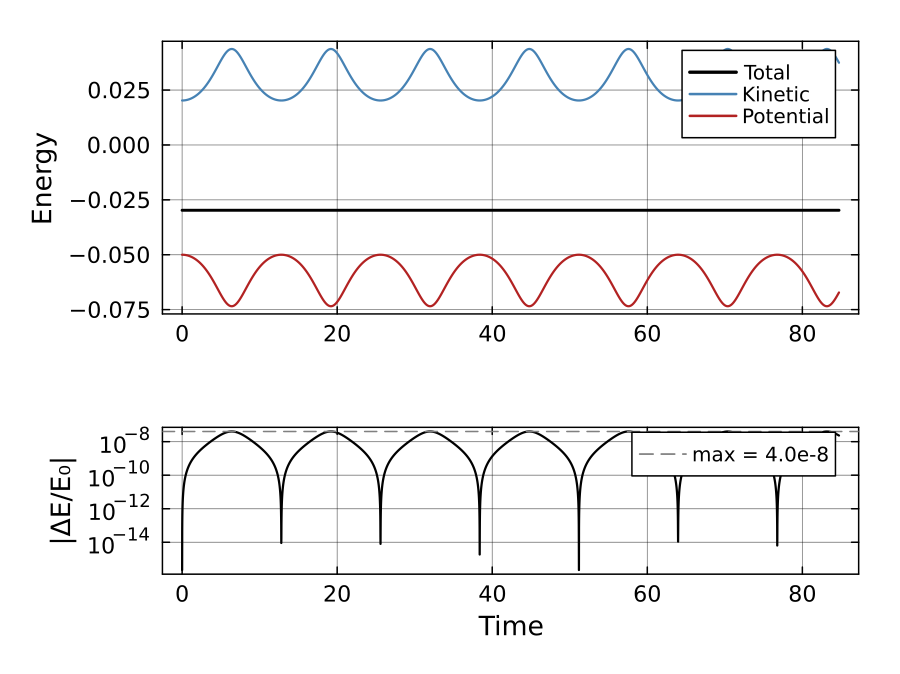

In [11]:
total_energy(q, p, params, t) = H_weber(q, p, params)

function kinetic_energy(q, p, params, t)
    m1, m2 = params[1], params[2]
    (p[1]^2 + p[2]^2)/(2m1) + (p[3]^2 + p[4]^2)/(2m2)
end

function potential_energy(q, p, params, t)
    m1, m2, k, c = params
    dx, dy = q[1] - q[3], q[2] - q[4]
    r = sqrt(dx^2 + dy^2)
    vx1, vy1 = p[1]/m1, p[2]/m1
    vx2, vy2 = p[3]/m2, p[4]/m2
    rdot = (dx*(vx1-vx2) + dy*(vy1-vy2)) / r
    k / r * (1 - rdot^2 / (2*c^2))
end

energy = compute_energy_timeseries(sol, total_energy, kinetic_energy, potential_energy, params; stride=10)

println("Max local error: ", energy.max_local_error)
println("Relative range: ", energy.relative_energy_range)

plot_energy(energy)

## Force Analysis

Newton's 3rd law max violation: 0.0


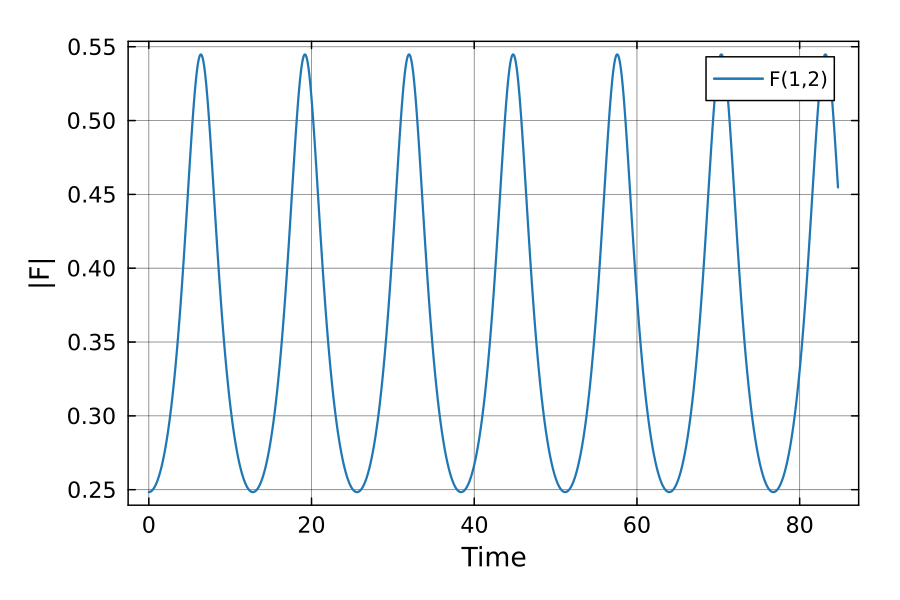

In [12]:
masses = [m1, m2]
charges = [1.0, -1.0]  # Opposite charges for attractive interaction

forces = compute_force_timeseries(sol, n_particles, dims, masses, charges, c; stride=10)

n3 = check_newtons_third_law(forces)
println("Newton's 3rd law max violation: ", n3.global_max_violation)

plot_forces(forces)

## Phase Space

## API Summary

| Category | Functions/Types |
|----------|----------------|
| **Hamiltonian** | `compile_hamiltonian`, `@hamiltonian`, `generate_phase_space_symbols` |
| **Problem** | `WeberProblem`, `SymmetricProjectionIntegrator`, `RelaxedFixedPointSolver` |
| **Integration** | `solve`, `init`, `step!`, `solve!` |
| **Trajectories** | `compute_trajectory_data` -> `TrajectoryData` -> `plot_trajectories` |
| **Energy** | `compute_energy_timeseries` -> `EnergyData` -> `plot_energy` |
| **Forces** | `compute_force_timeseries` -> `ForceData` -> `plot_forces`, `check_newtons_third_law` |
| **Phase Space** | `compute_phase_space_data` -> `PhaseSpaceData` -> `plot_phase_space` |